# Line shapes opcionais com SymPy

Este exemplo mostra como escrever uma expressão simbólica, **declarar explicitamente
seus parâmetros** e usá-la no mesmo `Resonance` das line shapes existentes.
`Pole()`, `GounarisSakurai()` e a criação de plugins em JAX continuam disponíveis.
O padrão de `Resonance` continua sendo `RelativisticBreitWigner()`.

**Instalação:** no terminal, na raiz do repositório, execute
`python -m pip install -e ".[sympy]"` e selecione o kernel desse ambiente.
Para abrir o notebook, instale também JupyterLab nesse ambiente, se necessário.
Execute as células na ordem. CPU é suficiente; nenhum arquivo de dados é necessário.

O exemplo inclui comparação com `Pole`, gráficos, parâmetros fixos/livres,
normalização de Dalitz, verificação de gradientes, ajuste Asimov e serialização.
As massas estão em GeV; o parâmetro exponencial `alpha` está em GeV⁻².

In [20]:
import json

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
from IPython.display import display

from dalitzplotfitter import (
    DecayChannel, DecayModel, Minimizer, NonResonant, Parameter,
    Pole, RealImag, Resonance, ResonanceContext, SympyLineshape,
    enable_x64,
)

enable_x64()
print(f"SymPy {sp.__version__}; JAX {jax.__version__}; dispositivo: {jax.devices()[0]}")

SymPy 1.14.0; JAX 0.11.1; dispositivo: cuda:0


## 1. Reproduzir uma line shape existente

A convenção de `Pole` no pacote é
\(R(m)=1/(m-m_0-i\Gamma_0/2)\).
`mass_symbol` indica a massa do par em cada evento. Nesta primeira expressão,
`context_symbols` obtém a massa e a largura do contexto do `Resonance`.
Os vínculos usam objetos `Symbol`, não textos com nomes.

In [21]:
m, m0, gamma, alpha, scale = sp.symbols("m m0 gamma alpha scale", real=True)
pole_expression = 1 / (m - m0 - sp.I * gamma / 2)
symbolic_pole = SympyLineshape(
    pole_expression,
    mass_symbol=m,
    context_symbols={m0: "pole_mass", gamma: "pole_width"},
)
context = ResonanceContext(
    parent_mass=1.86965, daughter_masses=(0.13957, 0.13957),
    bachelor_mass=0.13957, spin=0, pole_mass=0.77, pole_width=0.15,
)
mass_grid = jnp.linspace(0.30, 1.65, 500)
reference = Pole()(mass_grid, context)
symbolic = jax.jit(lambda x: symbolic_pole(x, context))(mass_grid)
np.testing.assert_allclose(symbolic, reference, rtol=1e-12, atol=1e-12)
print("Diferença máxima em relação a Pole:", float(jnp.max(jnp.abs(symbolic-reference))))
display(pole_expression)

Diferença máxima em relação a Pole: 0.0


1/(-I*gamma/2 + m - m0)

## 2. Declarar os parâmetros no wrapper

Agora multiplicamos o polo por `scale * exp(-alpha*m**2)`.
Cada entrada de `parameters` é uma constante numérica ou um `Parameter.dynamics`:

- `pole_mass`: livre, com limites e passo;
- `pole_width`: fixo neste ajuste (pode ser liberado em outro modelo);
- `damping`: livre, com um nome público independente do símbolo SymPy;
- `scale`: constante numérica.

`owner="custom"` deve coincidir com o nome do componente. Não ajustamos um fator
constante global da line shape: ele poderia ser redundante com o coeficiente complexo
ou desaparecer na normalização do componente.

In [22]:
pole_mass = Parameter.dynamics(
    "custom.mass", 0.73, owner="custom", bounds=(0.68, 0.85), step=0.001,
)
pole_width = Parameter.dynamics(
    "custom.width", 0.15, owner="custom", fixed=True,
    bounds=(0.05, 0.30), step=0.001,
)
damping = Parameter.dynamics(
    "custom.alpha", 0.15, owner="custom", bounds=(0.0, 1.5), step=0.01,
)
expression = scale * sp.exp(-alpha*m**2) * pole_expression
shape = SympyLineshape(
    expression,
    mass_symbol=m,
    parameters={m0: pole_mass, gamma: pole_width, alpha: damping, scale: 1.0},
)
display(expression)
display(pd.DataFrame([
    {"símbolo": str(symbol),
     "parâmetro": value.name if isinstance(value, Parameter) else "constante",
     "valor inicial": value.value if isinstance(value, Parameter) else value,
     "fixo": value.fixed if isinstance(value, Parameter) else True}
    for symbol, value in shape.parameters.items()
]))

scale*exp(-alpha*m**2)/(-I*gamma/2 + m - m0)

,símbolo,parâmetro,valor inicial,fixo
0,alpha,custom.alpha,0.15,False
1,gamma,custom.width,0.15,True
2,m0,custom.mass,0.73,False
3,scale,constante,1.00,True


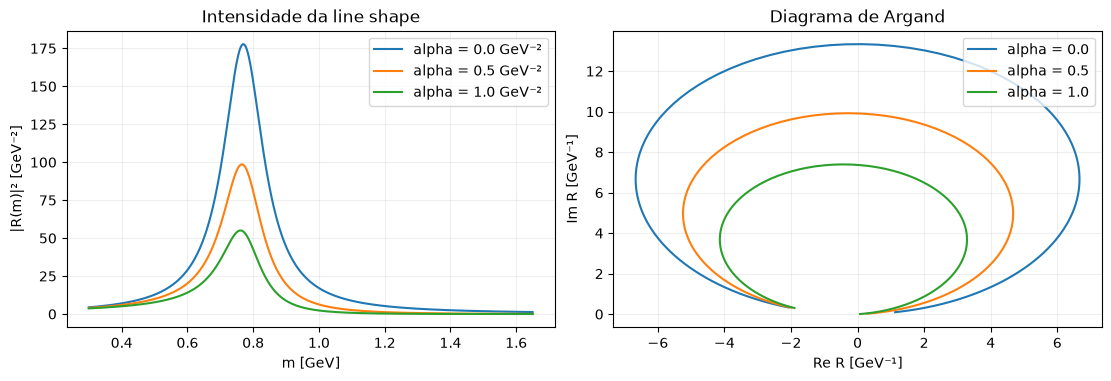

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.7), constrained_layout=True)
for a in (0.0, 0.5, 1.0):
    amplitude = np.asarray(shape.resolve({
        "custom.mass": 0.77, "custom.alpha": a,
    })(mass_grid, context))
    axes[0].plot(mass_grid, np.abs(amplitude)**2, label=f"alpha = {a:.1f} GeV⁻²")
    axes[1].plot(amplitude.real, amplitude.imag, label=f"alpha = {a:.1f}")
axes[0].set(xlabel="m [GeV]", ylabel="|R(m)|² [GeV⁻²]", title="Intensidade da line shape")
axes[1].set(xlabel="Re R [GeV⁻¹]", ylabel="Im R [GeV⁻¹]", title="Diagrama de Argand")
for ax in axes:
    ax.grid(alpha=0.2)
    ax.legend()
plt.show()

## 3. Usar a expressão no modelo de Dalitz

Reutilizamos os mesmos objetos de massa e largura em `Resonance`. Assim, os
metadados da integração e os fatores externos continuam consistentes com a fórmula.
A expressão representa apenas a line shape; o pacote combina os fatores angulares,
as barreiras e as permutações de partículas idênticas.

O modelo abaixo usa `D+ → pi- pi+ pi+`, uma contribuição escalar simbólica e uma
contribuição não ressonante. A coleta de parâmetros ocorre automaticamente.

In [24]:
model = DecayModel(
    DecayChannel("D+", ("pi-", "pi+", "pi+")),
    [
        Resonance(
            "custom", pair=(0, 1), coefficient=RealImag(0.65, -0.2),
            lineshape=shape, mass=pole_mass, width=pole_width, spin=0,
        ),
        NonResonant(RealImag(1.0, 0.0)),
    ],
    normalization_method="square-dalitz", normalization_resolution=40,
)
print("Parâmetros coletados:", [p.name for p in model.parameters])
assert {p.name for p in model.parameters} == {
    "custom.mass", "custom.width", "custom.alpha",
}

Parâmetros coletados: ['custom.alpha', 'custom.width', 'custom.mass']


## 4. Gradientes e ajuste Asimov

Para uma demonstração reprodutível, usamos um **ajuste Asimov**: uma soma ponderada
sobre pontos de integração com probabilidades calculadas nos parâmetros verdadeiros.
Não é uma amostra aleatória de eventos nem uma validação física da fórmula.

A normalização obedece à convenção do pacote, `mean(sample.weights * intensity)`.
Os mesmos pontos são usados para gerar e ajustar a distribuição discreta: a recuperação
valida a ligação dos parâmetros e o caminho do ajuste, mas não demonstra convergência
da integral contínua. Para uma análise, estude a resolução e use toys independentes.

In [25]:
sample = model.normalization_sample
cache = model.prepare_cache(sample, sample)
truth = {"custom.mass": 0.77, "custom.width": 0.15, "custom.alpha": 0.65}
truth_intensity, _ = cache.evaluate(truth)
probabilities = sample.weights * truth_intensity
probabilities = probabilities / jnp.sum(probabilities)

# O fator 2000 define apenas a escala do objetivo demonstrativo.
def asimov_nll(values):
    intensity, normalization = cache.evaluate(values)
    return 2000 * (
        -jnp.sum(probabilities * jnp.log(intensity)) + jnp.log(normalization)
    )

minimizer = Minimizer(asimov_nll, model.parameters, tolerance=1e-8)
gradient_check = minimizer.check_gradient(step_scale=1e-6)
np.testing.assert_allclose(
    gradient_check.jax_gradient, gradient_check.finite_difference_gradient,
    rtol=2e-5, atol=2e-5,
)
result = minimizer.fit(strategy=1)
assert result.valid, "O ajuste demonstrativo não convergiu"
summary = pd.DataFrame([
    {"parâmetro": p.name, "inicial": p.value, "verdade": truth[p.name],
     "ajustado": p.value if p.fixed else float(result.values[p.name]), "fixo": p.fixed}
    for p in model.parameters
])
display(summary)
assert abs(result.values["custom.mass"] - truth["custom.mass"]) < 2e-4
assert abs(result.values["custom.alpha"] - truth["custom.alpha"]) < 2e-3

parameter                     JAX    finite diff      abs err      rel err
custom.alpha         2.585635e+01   2.585635e+01    1.539e-07    5.954e-09
custom.mass         -2.028456e+03  -2.028456e+03    2.147e-07    1.059e-10
max abs error = 2.147e-07
max rel error = 5.954e-09


,parâmetro,inicial,verdade,ajustado,fixo
0,custom.alpha,0.15,0.65,0.650001,False
1,custom.width,0.15,0.15,0.150000,True
2,custom.mass,0.73,0.77,0.770000,False


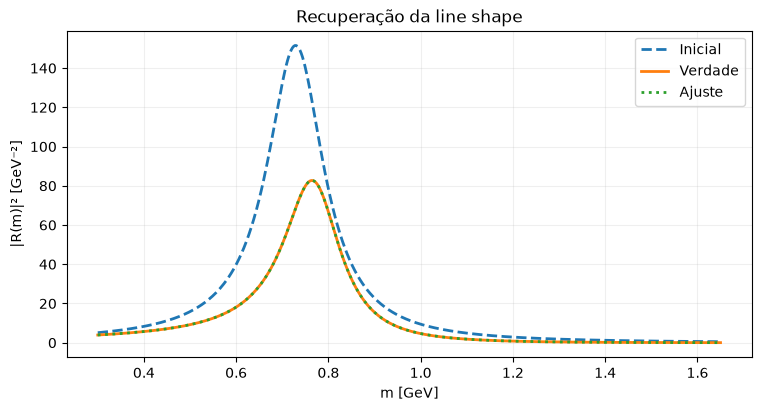

In [26]:
fig, ax = plt.subplots(figsize=(7.5, 4), constrained_layout=True)
for label, values, style in (
    ("Inicial", {}, "--"),
    ("Verdade", truth, "-"),
    ("Ajuste", result.values.to_dict(), ":"),
):
    amplitude = shape.resolve(values)(mass_grid, context)
    ax.plot(mass_grid, np.asarray(jnp.abs(amplitude)**2), style, label=label, linewidth=2)
ax.set(xlabel="m [GeV]", ylabel="|R(m)|² [GeV⁻²]", title="Recuperação da line shape")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## 5. Guardar a definição simbólica

`to_spec()` produz uma estrutura compatível com JSON. `from_spec()` reconstrói a
expressão e compila um novo kernel. A especificação contém a **declaração inicial**;
guarde os valores ajustados separadamente, como abaixo. Ela não salva o `DecayModel`,
a grade ou executáveis JAX.

O registro opcional preserva os mesmos objetos `Parameter` usados pelo `Resonance`.
Os leitores só reconstruem operações permitidas; não usam `eval` nem interpretam
uma fórmula arbitrária fornecida como texto.

In [27]:
record = {
    "lineshape": shape.to_spec(),
    "fit_values": {name: float(value) for name, value in result.values.to_dict().items()},
}
json_text = json.dumps(record, ensure_ascii=False, indent=2)
loaded = json.loads(json_text)
restored = SympyLineshape.from_spec(
    loaded["lineshape"], parameter_registry={p.name: p for p in model.parameters},
)
assert restored.parameters[m0] is pole_mass
np.testing.assert_allclose(
    restored.resolve(loaded["fit_values"])(mass_grid, context),
    shape.resolve(loaded["fit_values"])(mass_grid, context),
    rtol=1e-12,
)
print("Ida e volta por JSON verificada; tamanho:", len(json_text), "caracteres")

Ida e volta por JSON verificada; tamanho: 4879 caracteres


## 6. Domínio complexo e limites desta primeira versão

São aceitas expressões escalares com aritmética, potências, `exp`, `log`, funções
trigonométricas elementares, `Abs`, `re`, `im` e `conjugate`. A lista exata está na
documentação. Símbolos sem vínculo são rejeitados na construção.

Por padrão, raízes de argumentos reais negativos retornam `NaN`. Para continuação
complexa, `complex_domain=True` converte os argumentos antes de avaliar a expressão:
usa os ramos principais de raízes/logaritmos, sem escolher automaticamente uma folha
física. As hipóteses SymPy devem ser coerentes com o domínio pretendido.

`Piecewise`, funções simbólicas arbitrárias, matrizes, derivadas e integrais não
avaliadas ainda não são aceitas. Não há fallback para NumPy. Limiares e singularidades
podem ter derivadas indefinidas; não avalie exatamente neles ao validar gradientes.

As posições de estruturas estreitas adicionais dentro da expressão não são detectadas
pela integração adaptativa. Confira a convergência da normalização. Para alterar a
expressão ou liberar um parâmetro fixo, construa um novo wrapper/modelo/cache.

In [28]:
threshold = SympyLineshape(
    sp.sqrt(1 - m0**2 / m**2), mass_symbol=m,
    parameters={m0: 1.0}, complex_domain=True,
)
print("Abaixo/acima do limiar:", threshold(jnp.array([0.8, 1.2]), context))

Abaixo/acima do limiar: [0.       +0.75j 0.5527708+0.j  ]
